---
## Section 1 - Install & Import Libraries

In [ ]:
# Install required packages
!pip install google-play-scraper -q
!pip install nltk -q
!pip install pandas matplotlib seaborn wordcloud -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Google Play Scraper
from google_play_scraper import reviews, Sort

# NLTK
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


---
## Section 2 - Data Collection

We scrape reviews from the **Shopee Malaysia** app on Google Play.
- Package ID: `com.shopee.my`
- Language: English (`en`)
- Country: Malaysia (`my`)
- Target: 3,000 reviews across multiple batches


In [ ]:
# ============================================================
# Configuration
# ============================================================
APP_ID = 'com.shopee.my'       # Shopee Malaysia package ID
LANGUAGE = 'en'                 # English reviews only
COUNTRY = 'my'                  # Malaysia store
TARGET_REVIEWS = 3000           # How many reviews to collect
BATCH_SIZE = 200                # Reviews per API call (max 200)

print(f"Target: {TARGET_REVIEWS} reviews from {APP_ID}")

Target: 3000 reviews from com.shopee.my


In [ ]:
# ============================================================
# Scrape reviews in batches
# ============================================================
all_reviews = []
continuation_token = None
batch_count = 0

print("Starting data collection...")

while len(all_reviews) < TARGET_REVIEWS:
    try:
        result, continuation_token = reviews(
            APP_ID,
            lang=LANGUAGE,
            country=COUNTRY,
            sort=Sort.NEWEST,
            count=BATCH_SIZE,
            continuation_token=continuation_token
        )

        if not result:
            print("No more reviews available.")
            break

        all_reviews.extend(result)
        batch_count += 1
        print(f"Batch {batch_count}: Collected {len(result)} reviews | Total so far: {len(all_reviews)}")

        # Polite delay to avoid rate limiting
        time.sleep(1)

        if continuation_token is None:
            print("Reached end of available reviews.")
            break

    except Exception as e:
        print(f"Error on batch {batch_count + 1}: {e}")
        time.sleep(5)  # Wait longer on error
        break

print(f"\nCollection complete. Total reviews collected: {len(all_reviews)}")

Starting data collection...
Batch 1: Collected 200 reviews | Total so far: 200
Batch 2: Collected 200 reviews | Total so far: 400
Batch 3: Collected 200 reviews | Total so far: 600
Batch 4: Collected 200 reviews | Total so far: 800
Batch 5: Collected 200 reviews | Total so far: 1000
Batch 6: Collected 200 reviews | Total so far: 1200
Batch 7: Collected 200 reviews | Total so far: 1400
Batch 8: Collected 200 reviews | Total so far: 1600
Batch 9: Collected 200 reviews | Total so far: 1800
Batch 10: Collected 200 reviews | Total so far: 2000
Batch 11: Collected 200 reviews | Total so far: 2200
Batch 12: Collected 200 reviews | Total so far: 2400
Batch 13: Collected 200 reviews | Total so far: 2600
Batch 14: Collected 200 reviews | Total so far: 2800
Batch 15: Collected 200 reviews | Total so far: 3000

Collection complete. Total reviews collected: 3000


In [ ]:
# ============================================================
# Convert to DataFrame and keep relevant columns
# ============================================================
df_raw = pd.DataFrame(all_reviews)

# Keep only the columns we need
df_raw = df_raw[['reviewId', 'content', 'score', 'at', 'thumbsUpCount']].copy()

# Rename for clarity
df_raw.rename(columns={
    'reviewId': 'review_id',
    'content': 'review_text',
    'score': 'star_rating',
    'at': 'review_date',
    'thumbsUpCount': 'thumbs_up'
}, inplace=True)

print(f"DataFrame shape: {df_raw.shape}")
print(f"\nColumn info:")
print(df_raw.dtypes)
print(f"\nFirst 3 rows:")
df_raw.head(3)

DataFrame shape: (3000, 5)

Column info:
review_id              object
review_text            object
star_rating             int64
review_date    datetime64[ns]
thumbs_up               int64
dtype: object

First 3 rows:


,review_id,review_text,star_rating,review_date,thumbs_up
0,d006c8e9-db89-4633-946b-4cf3619284ff,The price is misleading. It only shows the dis...,1,2026-06-26 09:17:43,3
1,9714ab55-df50-42db-9dea-257928ccf00f,shopee Food so bad (no driver?) wait 1 hour al...,1,2026-06-26 09:13:22,0
2,3289def2-fbcf-4750-8e93-fbef2ffca159,Please keep up the good work. Thank you.,5,2026-06-26 09:01:31,1


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# The original path now that the duplicate shortcuts are gone
FILE_PATH = '/content/drive/MyDrive/Project2_SparklingSparkmind/Data/raw_data/raw_reviews.csv'

# Read the file directly
df = pd.read_csv(FILE_PATH)

print("Finally! File loaded successfully from the clean path.")
print(df.head())

Finally! File loaded successfully from the clean path.
                              review_id  \
0  72546d2e-d59e-4f67-a594-26f7c232f49f   
1  fe5dd4c3-e9ad-4976-868a-052a88636e8e   
2  5f641429-a969-400c-b5ba-246866ad9b88   
3  455f1e09-1ae8-4667-aaa5-b97e7d839cb6   
4  3317fdc1-43fb-457e-a8cd-37b0d302ca66   

                                         review_text  star_rating  \
0                                       good service            5   
1  app kdang2 pukima skit.. failed utk buat onlin...            1   
2                                               good            5   
3                      good, easy for communication.            5   
4                                            terbaik            5   

           review_date  thumbs_up  
0  2026-06-25 08:07:29          0  
1  2026-06-25 07:38:56          0  
2  2026-06-25 07:38:29          0  
3  2026-06-25 07:36:48          0  
4  2026-06-25 07:32:46          0  


---
## Section 3 - Exploratory Data Analysis (EDA)

Before cleaning, we inspect the raw data to understand its structure and quality.


In [ ]:
# Basic stats
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total reviews:       {len(df_raw):,}")
print(f"Missing review text: {df_raw['review_text'].isna().sum()}")
print(f"Duplicate reviews:   {df_raw.duplicated(subset='review_id').sum()}")
print(f"Date range:          {df_raw['review_date'].min()} to {df_raw['review_date'].max()}")
print()

print("Star rating distribution:")
print(df_raw['star_rating'].value_counts().sort_index())

DATASET OVERVIEW
Total reviews:       3,000
Missing review text: 0
Duplicate reviews:   0
Date range:          2026-04-25 13:47:00 to 2026-06-26 09:17:43

Star rating distribution:
star_rating
1     673
2     103
3      80
4     118
5    2026
Name: count, dtype: int64


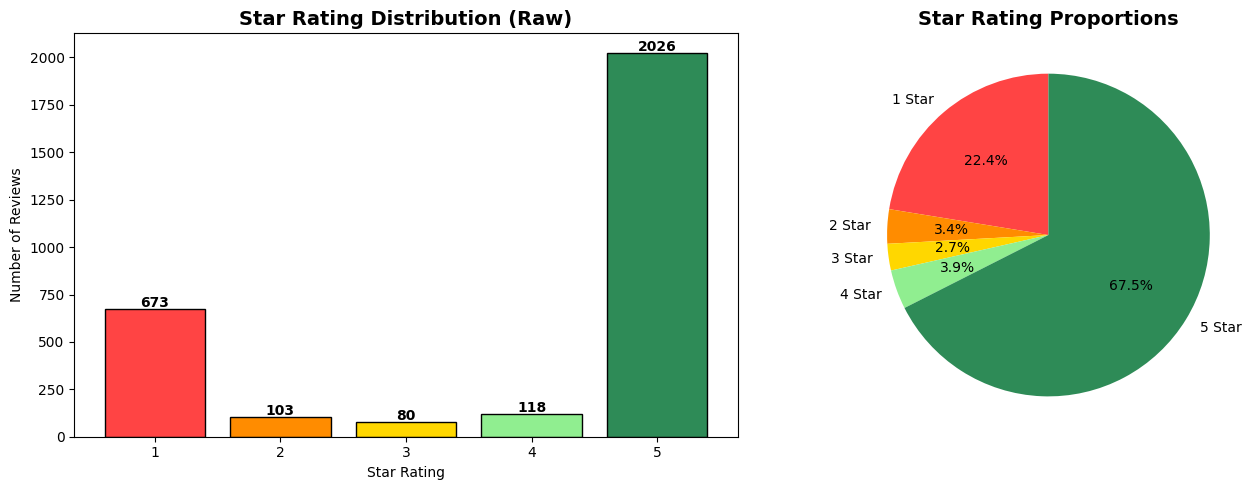

Chart saved: star_rating_distribution.png


In [ ]:
# Plot star rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
star_counts = df_raw['star_rating'].value_counts().sort_index()
colors = ['#FF4444', '#FF8C00', '#FFD700', '#90EE90', '#2E8B57']
axes[0].bar(star_counts.index, star_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Star Rating Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (rating, count) in enumerate(star_counts.items()):
    axes[0].text(rating, count + 10, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(star_counts.values, labels=[f'{i} Star' for i in star_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Star Rating Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('star_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: star_rating_distribution.png")

Review text length stats (characters):
count    3000.0
mean       81.0
std       111.8
min         1.0
25%         9.0
50%        31.0
75%       106.2
max       500.0
Name: text_length, dtype: float64


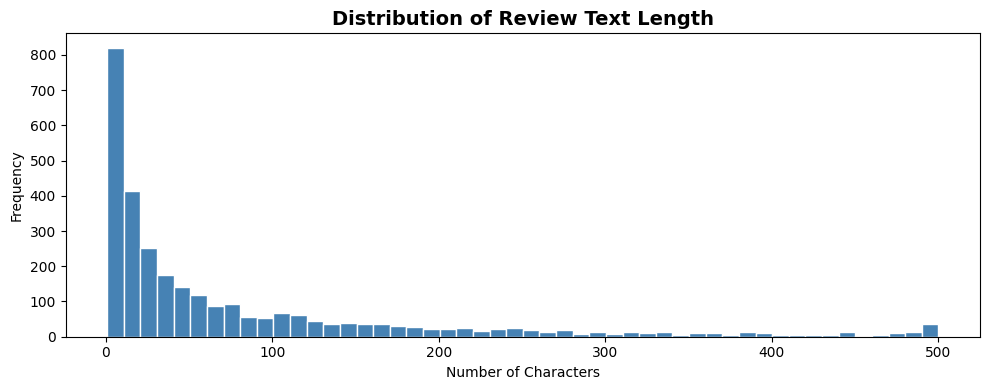

In [ ]:
# Review length analysis
df_raw['text_length'] = df_raw['review_text'].fillna('').apply(len)

print("Review text length stats (characters):")
print(df_raw['text_length'].describe().round(1))

plt.figure(figsize=(10, 4))
plt.hist(df_raw['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Review Text Length', fontsize=14, fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 - Sentiment Labelling

We map star ratings to sentiment labels:

| Star Rating | Sentiment |
|---|---|
| 4–5 stars | Positive |
| 3 stars | Neutral |
| 1–2 stars | Negative |

In [ ]:
def assign_sentiment(star_rating):
    """
    Map Google Play star ratings to sentiment labels.
    4-5 stars = positive, 3 stars = neutral, 1-2 stars = negative
    """
    if star_rating >= 4:
        return 'positive'
    elif star_rating == 3:
        return 'neutral'
    else:
        return 'negative'

df_raw['sentiment'] = df_raw['star_rating'].apply(assign_sentiment)

print("Sentiment label distribution:")
sentiment_counts = df_raw['sentiment'].value_counts()
print(sentiment_counts)
print()
print("Sentiment percentages:")
print((sentiment_counts / len(df_raw) * 100).round(2).astype(str) + '%')

Sentiment label distribution:
sentiment
positive    2144
negative     776
neutral       80
Name: count, dtype: int64

Sentiment percentages:
sentiment
positive    71.47%
negative    25.87%
neutral      2.67%
Name: count, dtype: object


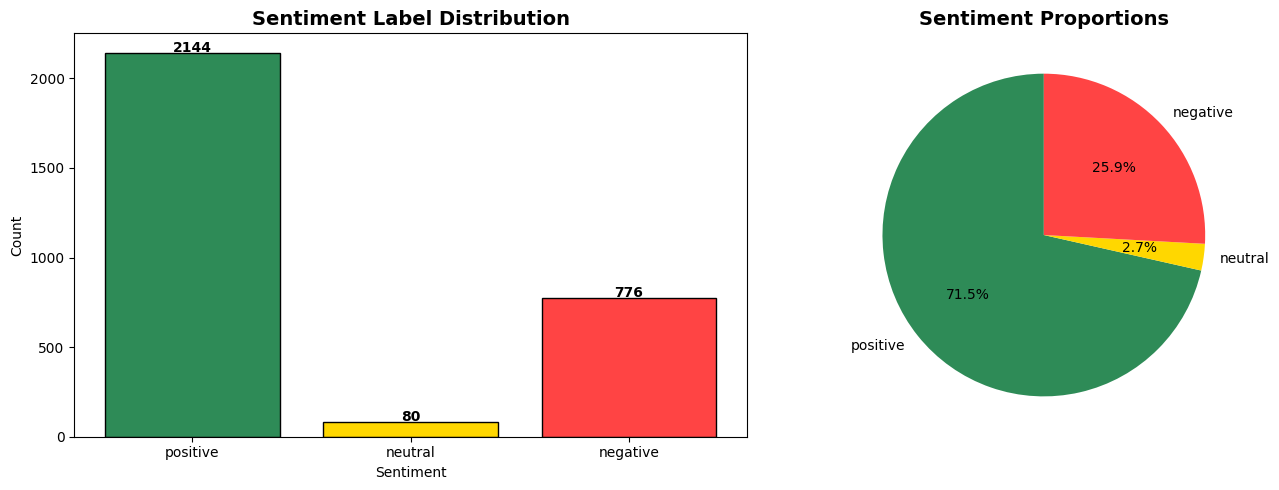

Chart saved: sentiment_distribution.png


In [ ]:
# Visualize sentiment distribution
colors_sentiment = {'positive': '#2E8B57', 'neutral': '#FFD700', 'negative': '#FF4444'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sentiment_order = ['positive', 'neutral', 'negative']
counts = [sentiment_counts.get(s, 0) for s in sentiment_order]
bar_colors = [colors_sentiment[s] for s in sentiment_order]

axes[0].bar(sentiment_order, counts, color=bar_colors, edgecolor='black')
axes[0].set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, count in enumerate(counts):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=sentiment_order, colors=bar_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: sentiment_distribution.png")

---
## Section 5 - Text Preprocessing

We apply standard NLP preprocessing steps as required by the brief:

1. **Remove nulls and duplicates**
2. **Lowercase conversion**
3. **Remove noise** - URLs, email addresses, mentions (@), hashtags (#), numbers, special characters
4. **Tokenization** - split text into individual words
5. **Stopword removal** - remove common words with little meaning
6. **Lemmatization** - reduce words to their base form

In [ ]:
# ============================================================
# Step 1: Remove null and duplicate reviews
# ============================================================
df = df_raw.copy()

before = len(df)
df.dropna(subset=['review_text'], inplace=True)
df = df[df['review_text'].str.strip() != '']  # Remove empty strings
df.drop_duplicates(subset='review_id', inplace=True)
after = len(df)

print(f"Records before cleaning: {before:,}")
print(f"Records after removing nulls/duplicates: {after:,}")
print(f"Removed: {before - after:,} records")

Records before cleaning: 3,000
Records after removing nulls/duplicates: 3,000
Removed: 0 records


In [ ]:
# ============================================================
# Step 2-6: Full preprocessing pipeline
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom stopwords relevant to app reviews
custom_stopwords = {'app', 'shopee', 'please', 'really', 'would', 'also',
                    'get', 'use', 'used', 'using', 'one', 'like', 'even',
                    'still', 'much', 'many', 'every', 'could', 'well'}
stop_words.update(custom_stopwords)

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove email addresses
    4. Remove @mentions and #hashtags
    5. Remove numbers
    6. Remove special characters (keep only letters and spaces)
    7. Tokenize
    8. Remove stopwords
    9. Lemmatize
    10. Remove short tokens (< 2 characters)
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Step 4: Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 5: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 6: Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 7: Tokenize
    tokens = word_tokenize(text)

    # Step 8: Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Step 9: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Preprocessing function defined. Applying to dataset...")
print("This may take a minute for large datasets.\n")

# Apply preprocessing
df['cleaned_text'] = df['review_text'].apply(preprocess_text)

print("Preprocessing complete!")
print(f"Total processed: {len(df):,} reviews")

Preprocessing function defined. Applying to dataset...
This may take a minute for large datasets.

Preprocessing complete!
Total processed: 3,000 reviews


In [ ]:
# ============================================================
# Show before/after examples
# ============================================================
print("BEFORE vs AFTER PREPROCESSING EXAMPLES")
print("=" * 70)

sample_indices = df.sample(5, random_state=42).index

for i, idx in enumerate(sample_indices):
    print(f"\nExample {i+1} [{df.loc[idx, 'sentiment'].upper()}]")
    print(f"  BEFORE: {df.loc[idx, 'review_text'][:200]}")
    print(f"  AFTER:  {df.loc[idx, 'cleaned_text'][:200]}")
    print("-" * 70)

BEFORE vs AFTER PREPROCESSING EXAMPLES

Example 1 [POSITIVE]
  BEFORE: this is the best shopping app
  AFTER:  best shopping
----------------------------------------------------------------------

Example 2 [POSITIVE]
  BEFORE: ok sng nk gna
  AFTER:  sng gna
----------------------------------------------------------------------

Example 3 [POSITIVE]
  BEFORE: best
  AFTER:  best
----------------------------------------------------------------------

Example 4 [POSITIVE]
  BEFORE: puas Hati Beli d shopee
  AFTER:  puas hati beli
----------------------------------------------------------------------

Example 5 [POSITIVE]
  BEFORE: puasa hati
  AFTER:  puasa hati
----------------------------------------------------------------------


In [ ]:
# ============================================================
# Remove reviews with empty cleaned text
# (reviews that had only numbers/emojis become empty after cleaning)
# ============================================================
before_empty = len(df)
df = df[df['cleaned_text'].str.strip() != '']
after_empty = len(df)

print(f"Removed {before_empty - after_empty} reviews that became empty after cleaning.")
print(f"Final dataset size: {after_empty:,} reviews")

Removed 104 reviews that became empty after cleaning.
Final dataset size: 2,896 reviews


In [ ]:
# ============================================================
# Token count analysis after preprocessing
# ============================================================
df['token_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print("Token count stats after preprocessing:")
print(df['token_count'].describe().round(2))

# Filter: keep reviews with at least 3 tokens (too short = not useful for model)
before_filter = len(df)
df = df[df['token_count'] >= 3]
after_filter = len(df)

print(f"\nRemoved {before_filter - after_filter} reviews with fewer than 3 tokens.")
print(f"Final clean dataset: {after_filter:,} reviews")

Token count stats after preprocessing:
count    2896.00
mean        8.46
std        11.00
min         1.00
25%         1.00
50%         4.00
75%        11.00
max        79.00
Name: token_count, dtype: float64

Removed 1186 reviews with fewer than 3 tokens.
Final clean dataset: 1,710 reviews


---
## Section 6 - Export Cleaned Data

Save the final cleaned dataset for the modelling team.

In [ ]:
# ============================================================
# Prepare final cleaned dataset
# ============================================================
df_cleaned = df[['review_id', 'review_text', 'cleaned_text', 'star_rating',
                  'sentiment', 'review_date', 'token_count']].copy()

# Reset index
df_cleaned.reset_index(drop=True, inplace=True)

print("Final cleaned dataset:")
print(f"  Shape: {df_cleaned.shape}")
print(f"  Columns: {list(df_cleaned.columns)}")
print()

print("Sentiment breakdown:")
print(df_cleaned['sentiment'].value_counts())
print()

df_cleaned.head(5)

Final cleaned dataset:
  Shape: (1710, 7)
  Columns: ['review_id', 'review_text', 'cleaned_text', 'star_rating', 'sentiment', 'review_date', 'token_count']

Sentiment breakdown:
sentiment
positive    951
negative    691
neutral      68
Name: count, dtype: int64



,review_id,review_text,cleaned_text,star_rating,sentiment,review_date,token_count
0,d006c8e9-db89-4633-946b-4cf3619284ff,The price is misleading. It only shows the dis...,price misleading show discounted price applyin...,1,negative,2026-06-26 09:17:43,19
1,9714ab55-df50-42db-9dea-257928ccf00f,shopee Food so bad (no driver?) wait 1 hour al...,food bad driver wait hour assign driver eat ti...,1,negative,2026-06-26 09:13:22,24
2,3289def2-fbcf-4750-8e93-fbef2ffca159,Please keep up the good work. Thank you.,keep good work thank,5,positive,2026-06-26 09:01:31,4
3,8b499a43-c3f0-4dfd-8273-bdec1c0ba2c1,"Shopping made easier, no fuss when returning i...",shopping made easier fuss returning item best ...,5,positive,2026-06-26 08:47:46,10
4,a0d7a36e-daa3-4c28-85f1-5c3cbff8c541,become more complicated in reviewing. coin mac...,become complicated reviewing coin macam tak ik...,2,negative,2026-06-26 08:47:14,9


In [ ]:
import os
import shutil

GROUP_FOLDER = '/content/drive/MyDrive/Project2_SparklingSparkmind/Data'

# Save cleaned data to Colab temp first
df_cleaned.to_csv('cleaned_data.csv', index=False)

# Copy to Drive
shutil.copy('cleaned_data.csv', GROUP_FOLDER + '/cleaned_data.csv')

print("cleaned_data.csv saved to Google Drive!")
print(f"Location: {GROUP_FOLDER}/cleaned_data.csv")

cleaned_data.csv saved to Google Drive!
Location: /content/drive/MyDrive/Project2_SparklingSparkmind/Data/cleaned_data.csv


---
## Section 7 - Final Summary


In [ ]:
print("=" * 60)
print("MEMBER 1 — DATA ACQUISITION & PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\nData Source:      Shopee Malaysia (com.shopee.my) — Google Play")
print(f"Language:         English (en) | Country: Malaysia (my)")
print(f"Raw Reviews:      {len(df_raw):,}")
print(f"Cleaned Reviews:  {len(df_cleaned):,}")
print()
print("Preprocessing Steps Applied:")
print("  1. Removed null and duplicate entries")
print("  2. Converted text to lowercase")
print("  3. Removed URLs, emails, mentions, hashtags")
print("  4. Removed numbers and special characters")
print("  5. Tokenized using NLTK word_tokenize")
print("  6. Removed English stopwords + custom app-specific stopwords")
print("  7. Applied WordNet Lemmatization")
print("  8. Removed reviews with fewer than 3 tokens")
print()
print("Sentiment Label Mapping:")
print("  4-5 stars → Positive")
print("  3 stars   → Neutral")
print("  1-2 stars → Negative")
print()
print("Final Sentiment Distribution:")
for sentiment, count in df_cleaned['sentiment'].value_counts().items():
    pct = count / len(df_cleaned) * 100
    print(f"  {sentiment.capitalize():10s}: {count:,} ({pct:.1f}%)")
print()
print("Output Files:")
print("  raw_reviews.csv                — Original scraped data")
print("  cleaned_data.csv               — Preprocessed data (for Member 2)")
print("  star_rating_distribution.png   — EDA chart")
print("  sentiment_distribution.png     — Sentiment labels chart")
print("  wordcloud_positive.png         — Word cloud (positive)")
print("  wordcloud_negative.png         — Word cloud (negative)")
print("  top_words_by_sentiment.png     — Top words per class")
print("  sentiment_over_time.png        — Monthly trend")
print("=" * 60)

MEMBER 1 — DATA ACQUISITION & PREPROCESSING SUMMARY

Data Source:      Shopee Malaysia (com.shopee.my) — Google Play
Language:         English (en) | Country: Malaysia (my)
Raw Reviews:      3,000
Cleaned Reviews:  1,710

Preprocessing Steps Applied:
  1. Removed null and duplicate entries
  2. Converted text to lowercase
  3. Removed URLs, emails, mentions, hashtags
  4. Removed numbers and special characters
  5. Tokenized using NLTK word_tokenize
  6. Removed English stopwords + custom app-specific stopwords
  7. Applied WordNet Lemmatization
  8. Removed reviews with fewer than 3 tokens

Sentiment Label Mapping:
  4-5 stars → Positive
  3 stars   → Neutral
  1-2 stars → Negative

Final Sentiment Distribution:
  Positive  : 951 (55.6%)
  Negative  : 691 (40.4%)
  Neutral   : 68 (4.0%)

Output Files:
  raw_reviews.csv                — Original scraped data
  cleaned_data.csv               — Preprocessed data (for Member 2)
  star_rating_distribution.png   — EDA chart
  sentiment_dist

In [ ]:
print(df_cleaned['sentiment'].value_counts())
print()
print((df_cleaned['sentiment'].value_counts() / len(df_cleaned) * 100).round(1).astype(str) + '%')

sentiment
positive    951
negative    691
neutral      68
Name: count, dtype: int64

sentiment
positive    55.6%
negative    40.4%
neutral      4.0%
Name: count, dtype: object
